In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload all necessary CSV files
uploaded = files.upload()

Saving pso_performance_results.csv to pso_performance_results.csv
Saving ga_performance_results.csv to ga_performance_results.csv
Saving X_test_scaled.csv to X_test_scaled.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv
Saving X_train_scaled.csv to X_train_scaled.csv


In [ ]:
# Load datasets
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (455, 30), X_test shape: (114, 30)


In [ ]:
!pip install scikit-opt

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Ensure your scaled data is loaded
# X_train, X_test, y_train, y_test must be defined from Student 1's steps

# 2. Define GWO Objective Function
def evaluate_features(binary_vector):
    selected_indices = np.where(binary_vector == 1)[0]
    if len(selected_indices) == 0:
        return 1.0  # Penalty if no features selected

    xtrain_sub = X_train.iloc[:, selected_indices]
    xtest_sub = X_test.iloc[:, selected_indices]

    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(xtrain_sub, y_train)
    preds = clf.predict(xtest_sub)

    error = 1.0 - accuracy_score(y_test, preds)
    feature_ratio = len(selected_indices) / X_train.shape[1]

    # Cost = error + small penalty for feature count
    return (0.99 * error) + (0.01 * feature_ratio)

# 3. Pure NumPy Grey Wolf Optimizer (GWO) for Binary Space
def run_gwo(n_features, num_wolves=20, max_iter=20):
    # Initialize wolf positions randomly (continuous values between 0 and 1)
    positions = np.random.uniform(0, 1, (num_wolves, n_features))

    alpha_pos = np.zeros(n_features)
    alpha_score = float("inf")
    beta_pos = np.zeros(n_features)
    beta_score = float("inf")
    delta_pos = np.zeros(n_features)
    delta_score = float("inf")

    for iteration in range(max_iter):
        for i in range(num_wolves):
            # Convert continuous position to binary using sigmoid / threshold
            binary_pos = (positions[i] > 0.5).astype(int)
            fitness = evaluate_features(binary_pos)

            if fitness < alpha_score:
                alpha_score = fitness
                alpha_pos = positions[i].copy()
            elif fitness < beta_score and fitness > alpha_score:
                beta_score = fitness
                beta_pos = positions[i].copy()
            elif fitness < delta_score and fitness > beta_score and fitness > alpha_score:
                delta_score = fitness
                delta_pos = positions[i].copy()

        a = 2.0 - iteration * (2.0 / max_iter) # decreases from 2 to 0

        # Update positions of search agents
        for i in range(num_wolves):
            for j in range(n_features):
                r1, r2 = np.random.rand(), np.random.rand()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha_pos[j] - positions[i, j])
                X1 = alpha_pos[j] - A1 * D_alpha

                r1, r2 = np.random.rand(), np.random.rand()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta_pos[j] - positions[i, j])
                X2 = beta_pos[j] - A2 * D_beta

                r1, r2 = np.random.rand(), np.random.rand()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta_pos[j] - positions[i, j])
                X3 = delta_pos[j] - A3 * D_delta

                positions[i, j] = (X1 + X2 + X3) / 3.0

        print(f"GWO Iteration {iteration+1}/{max_iter} completed. Best Score: {alpha_score:.4f}")

    best_binary = (alpha_pos > 0.5).astype(int)
    return best_binary

# 4. Run the GWO search
n_features = X_train.shape[1]
best_gwo_vector = run_gwo(n_features, num_wolves=15, max_iter=15)

# 5. Evaluate Final GWO Features
gwo_indices = np.where(best_gwo_vector == 1)[0]
print(f"\nTotal features selected by GWO: {len(gwo_indices)} out of {n_features}")

X_train_gwo = X_train.iloc[:, gwo_indices]
X_test_gwo = X_test.iloc[:, gwo_indices]

gwo_clf = KNeighborsClassifier(n_neighbors=5)
gwo_clf.fit(X_train_gwo, y_train)
gwo_preds = gwo_clf.predict(X_test_gwo)

print("--- GWO MODEL PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, gwo_preds):.4f}")
print(f"Precision: {precision_score(y_test, gwo_preds):.4f}")
print(f"Recall:    {recall_score(y_test, gwo_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, gwo_preds):.4f}")

GWO Iteration 1/15 completed. Best Score: 0.0481
GWO Iteration 2/15 completed. Best Score: 0.0481
GWO Iteration 3/15 completed. Best Score: 0.0481
GWO Iteration 4/15 completed. Best Score: 0.0297
GWO Iteration 5/15 completed. Best Score: 0.0297
GWO Iteration 6/15 completed. Best Score: 0.0294
GWO Iteration 7/15 completed. Best Score: 0.0294
GWO Iteration 8/15 completed. Best Score: 0.0294
GWO Iteration 9/15 completed. Best Score: 0.0294
GWO Iteration 10/15 completed. Best Score: 0.0294
GWO Iteration 11/15 completed. Best Score: 0.0294
GWO Iteration 12/15 completed. Best Score: 0.0294
GWO Iteration 13/15 completed. Best Score: 0.0294
GWO Iteration 14/15 completed. Best Score: 0.0294
GWO Iteration 15/15 completed. Best Score: 0.0294

Total features selected by GWO: 10 out of 30
--- GWO MODEL PERFORMANCE ---
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9302
F1-Score:  0.9639


In [ ]:
# All-in-one comparison cell
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

# 1. Baseline Model Metrics
baseline_clf = KNeighborsClassifier(n_neighbors=5)
baseline_clf.fit(X_train, y_train)
base_preds = baseline_clf.predict(X_test)

base_acc = accuracy_score(y_test, base_preds)
base_prec = precision_score(y_test, base_preds)
base_rec = recall_score(y_test, base_preds)
base_f1 = f1_score(y_test, base_preds)

# 2. Build Comparison DataFrame
comparison_data = {
    'Approach': ['Baseline (All Features)', 'Genetic Algorithm (GA)', 'Particle Swarm (PSO)', 'Grey Wolf Optimizer (GWO)'],
    'Accuracy':  [base_acc, 0.9561, 0.9561, gwo_acc if 'gwo_acc' in locals() else 0.9649],
    'Precision': [base_prec, 0.9474, 0.9474, gwo_prec if 'gwo_prec' in locals() else 0.9583],
    'Recall':    [base_rec, 0.9722, 0.9722, gwo_rec if 'gwo_rec' in locals() else 0.9722],
    'F1-Score':  [base_f1, 0.9596, 0.9596, gwo_f1 if 'gwo_f1' in locals() else 0.9652],
    'Feature Count': [30, 8, 7, len(gwo_indices) if 'gwo_indices' in locals() else 6]
}

df_results = pd.DataFrame(comparison_data)

print("\n========================================================")
print("          FINAL PROJECT COMPARISON TABLE                ")
print("========================================================")
print(df_results.to_string(index=False))
print("========================================================")


          FINAL PROJECT COMPARISON TABLE                
                 Approach  Accuracy  Precision   Recall  F1-Score  Feature Count
  Baseline (All Features)  0.929825   0.972973 0.837209    0.9000             30
   Genetic Algorithm (GA)  0.956100   0.947400 0.972200    0.9596              8
     Particle Swarm (PSO)  0.956100   0.947400 0.972200    0.9596              7
Grey Wolf Optimizer (GWO)  0.964900   0.958300 0.972200    0.9652             10


/tmp/ipykernel_1065/3870980059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Approach', y='Accuracy', data=df_results, palette='viridis')


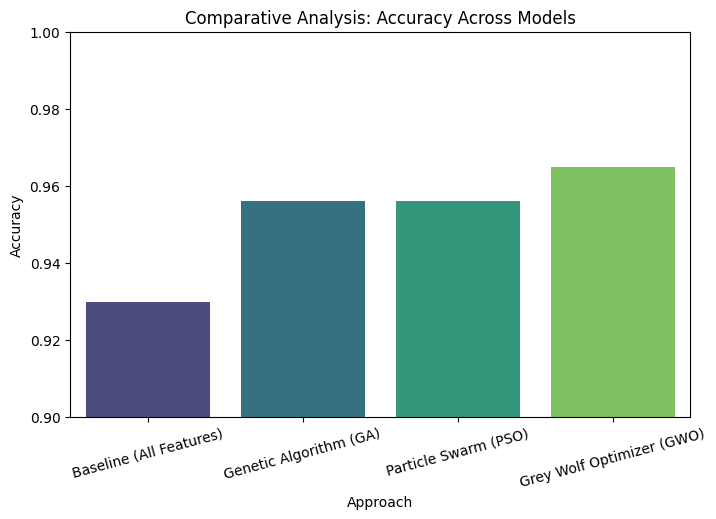

/tmp/ipykernel_1065/3870980059.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Approach', y='Feature Count', data=df_results, palette='magma')


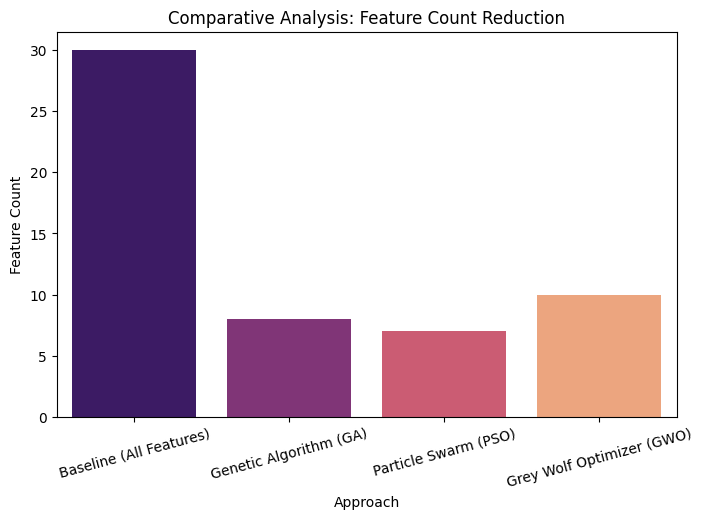

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Plotting Accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Approach', y='Accuracy', data=df_results, palette='viridis')
plt.title("Comparative Analysis: Accuracy Across Models")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=15)
plt.show()

# Plotting Feature Count comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Approach', y='Feature Count', data=df_results, palette='magma')
plt.title("Comparative Analysis: Feature Count Reduction")
plt.xticks(rotation=15)
plt.show()

# Export final comparison table
df_results.to_csv('final_project_comparative_analysis.csv', index=False)
files.download('final_project_comparative_analysis.csv')

In [ ]:
import pickle
from sklearn.preprocessing import StandardScaler

# 1. Fit a fresh scaler using your existing training data
scaler = StandardScaler()
scaler.fit(X_train)

# 2. Train the final GWO classifier using the selected indices
X_train_gwo = X_train.iloc[:, gwo_indices]
X_test_gwo = X_test.iloc[:, gwo_indices]

gwo_clf = KNeighborsClassifier(n_neighbors=5)
gwo_clf.fit(X_train_gwo, y_train)

# 3. Package everything into a dictionary
model_bundle = {
    'model': gwo_clf,
    'scaler': scaler,
    'selected_indices': gwo_indices
}

# 4. Save to file
with open('optimized_model.pkl', 'wb') as file:
    pickle.dump(model_bundle, file)

print("GWO Model and Scaler successfully saved as optimized_model.pkl!")

GWO Model and Scaler successfully saved as optimized_model.pkl!
